# Modeling2 — Car Breakdown Prediction

**Objective:** Outperform the baseline model (Gradient Boosting, ~16 class 1 predictions out of 450) by improving recall and F1 of the minority class (breakdowns).

| Target Metric | Baseline | Target |
|---|---|---|
| Recall clase 1 | ~0.05 | ≥ 0.50 |
| Precision clase 1 | — | ≥ 0.40 |
| F1 clase 1 | ~0.09 | ≥ 0.45 |
| Accuracy global | 0.83 | ≥ 0.80 |

## 1. Setup — Imports & Full Pipeline

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, recall_score, precision_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay, confusion_matrix,
    precision_recall_curve, roc_curve
)

# imbalanced-learn
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
print('✅ Imports OK')
print(f'   XGBoost {xgb.__version__}')

✅ Imports OK
   XGBoost 3.2.0


In [ ]:
# ── Cleaning function (self-contained) ────────────────────────────────────
def remove_impossible_values(df):
    mask = (
        (df['mileage_km'] < 0) |
        (df['mileage_km'] > 2_000_000) |
        (df['engine_hours'] < 0) |
        (df['oil_quality_pct'] > 100) |
        (df['cleanliness_score'] < 0) |
        (df['cleanliness_score'] > 100) |
        (df['driver_satisfaction_score'] > 10)
    )
    return df[~mask].copy(), mask.sum()

def add_engineered_features(df):
    """Adds domain features. Safe to apply to any df post-imputation."""
    d = df.copy()
    # Wear
    d['mileage_per_year']      = d['mileage_km'] / (d['vehicle_age_years'] + 1)
    d['hours_per_km']          = d['engine_hours'] / (d['mileage_km'] + 1)
    d['service_overdue_ratio'] = d['last_service_km_ago'] / (d['mileage_km'] + 1)
    # Risk flags
    d['is_service_overdue'] = (d['last_service_km_ago'] > 15000).astype(int)
    d['is_old_vehicle']     = (d['vehicle_age_years'] >= 15).astype(int)
    d['is_high_mileage']    = (d['mileage_km'] > 200000).astype(int)
    d['is_low_oil_quality'] = (d['oil_quality_pct'] < 30).astype(int)
    d['is_dirty']           = (d['cleanliness_score'] < 40).astype(int)
    # Interactions
    d['age_x_mileage']  = d['vehicle_age_years'] * np.log1p(d['mileage_km'])
    d['oil_x_service']  = d['oil_quality_pct'] * (1 / (d['last_service_km_ago'] + 1))
    # Log transforms
    d['log_mileage']      = np.log1p(d['mileage_km'])
    d['log_last_service'] = np.log1p(d['last_service_km_ago'])
    d['log_avg_trip']     = np.log1p(d['avg_trip_length_km'])
    # Composite risk score
    d['risk_score'] = (
        d['is_service_overdue'] * 3 +
        d['is_low_oil_quality'] * 2 +
        d['is_old_vehicle']     * 2 +
        d['is_high_mileage']        +
        d['is_dirty']
    )
    return d

print('✅ Functions defined')

✅ Functions defined


In [ ]:
# ── Loading and Cleaning ────────────────────────────────────────────────────────
df_train_raw = pd.read_csv('car-breakdown-prediction/train_CarBreakDown.csv')
df_test_raw  = pd.read_csv('car-breakdown-prediction/test_CarBreakDown.csv')

df_train, n_removed = remove_impossible_values(df_train_raw)
df_test = df_test_raw.copy()  # DO NOT remove rows from test

print(f'Train: {df_train_raw.shape[0]} → {df_train.shape[0]} ({n_removed} removed)')
print(f'Test : {df_test.shape[0]} rows (all are predicted)')

TARGET    = 'breakdown_next_30_days'
NUM_COLS  = ['vehicle_age_years', 'mileage_km', 'engine_hours',
             'last_service_km_ago', 'oil_quality_pct', 'avg_trip_length_km',
             'cleanliness_score', 'driver_satisfaction_score']
CAT_COLS  = ['vehicle_brand', 'weather_exposure', 'fuel_type', 'tyre_type']
ENG_COLS  = [
    'mileage_per_year', 'hours_per_km', 'service_overdue_ratio',
    'is_service_overdue', 'is_old_vehicle', 'is_high_mileage',
    'is_low_oil_quality', 'is_dirty',
    'age_x_mileage', 'oil_x_service',
    'log_mileage', 'log_last_service', 'log_avg_trip',
    'risk_score'
]
ALL_NUM   = NUM_COLS + ENG_COLS

# Apply feature engineering
df_train = add_engineered_features(df_train)
df_test  = add_engineered_features(df_test)

# Replace inf/nan in engineered features
for col in ENG_COLS:
    df_train[col] = df_train[col].replace([np.inf, -np.inf], np.nan)
    df_test[col]  = df_test[col].replace([np.inf, -np.inf], np.nan)

X_train_full = df_train[ALL_NUM + CAT_COLS]
y_train_full = df_train[TARGET]
X_test_sub   = df_test[ALL_NUM + CAT_COLS]

print(f'\nX_train_full : {X_train_full.shape}')
print(f'X_test_sub   : {X_test_sub.shape}')
print(f'\nTarget distribution:')
print(y_train_full.value_counts(normalize=True).round(3))

Train: 1050 → 963 (87 removed)
Test : 450 rows (all are predicted)

X_train_full : (963, 26)
X_test_sub   : (450, 26)

Target distribution:
breakdown_next_30_days
0    0.831
1    0.169
Name: proportion, dtype: float64


In [ ]:
# ── Stratified 80/20 Train/Val Split ────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, stratify=y_train_full, random_state=RANDOM_STATE
)
print(f'X_train: {X_train.shape}  |  y_train: {y_train.value_counts().to_dict()}')
print(f'X_val  : {X_val.shape}  |  y_val  : {y_val.value_counts().to_dict()}')

X_train: (770, 26)  |  y_train: {0: 640, 1: 130}
X_val  : (193, 26)  |  y_val  : {0: 160, 1: 33}


In [ ]:
# ── Preprocessor (reusable in all pipelines) ──────────────────────
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='other')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, ALL_NUM),
    ('cat', categorical_transformer, CAT_COLS)
])
print('✅ Preprocessor with', len(ALL_NUM), 'numerical features +', len(CAT_COLS), 'categorical')

✅ Preprocessor with 22 numerical features + 4 categorical


In [ ]:
# ── Full Evaluation Function ──────────────────────────────────────────
def evaluate_model(name, pipeline, X_tr, y_tr, X_v, y_v, threshold=0.5):
    """Trains and evaluates with full metrics. Supports custom threshold."""
    pipeline.fit(X_tr, y_tr)
    
    # Probabilities
    if hasattr(pipeline, 'predict_proba'):
        y_prob = pipeline.predict_proba(X_v)[:, 1]
    else:
        y_prob = pipeline.decision_function(X_v)
    
    y_pred = (y_prob >= threshold).astype(int)
    
    acc     = accuracy_score(y_v, y_pred)
    bal_acc = balanced_accuracy_score(y_v, y_pred)
    f1_c1   = f1_score(y_v, y_pred, pos_label=1, zero_division=0)
    rec_c1  = recall_score(y_v, y_pred, pos_label=1, zero_division=0)
    prec_c1 = precision_score(y_v, y_pred, pos_label=1, zero_division=0)
    auc     = roc_auc_score(y_v, y_prob)
    
    print(f'\n{"="*58}')
    print(f'  {name}  [threshold={threshold}]')
    print(f'{"="*58}')
    print(f'  Accuracy global    : {acc:.4f}')
    print(f'  Balanced Accuracy  : {bal_acc:.4f}')
    print(f'  F1 clase 1         : {f1_c1:.4f}')
    print(f'  Recall clase 1     : {rec_c1:.4f}')
    print(f'  Precision clase 1  : {prec_c1:.4f}')
    print(f'  ROC-AUC            : {auc:.4f}')
    print()
    print(classification_report(y_v, y_pred, target_names=['No breakdown (0)', 'Breakdown (1)']))
    
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_v, y_pred),
        display_labels=['No breakdown (0)', 'Breakdown (1)']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return {
        'model': name, 'threshold': threshold,
        'accuracy': round(acc, 4), 'balanced_accuracy': round(bal_acc, 4),
        'f1_class1': round(f1_c1, 4), 'recall_class1': round(rec_c1, 4),
        'precision_class1': round(prec_c1, 4), 'roc_auc': round(auc, 4),
        'pipeline': pipeline, 'y_prob': y_prob
    }

def predict_with_threshold(pipeline, X, threshold=0.5):
    prob = pipeline.predict_proba(X)[:, 1]
    return (prob >= threshold).astype(int), prob

results = []
print('✅ Evaluation functions ready')

✅ Evaluation functions ready


## 2. Baseline Reproduction

We replicate the original model (GradientBoosting without class_weight, threshold=0.5) to confirm the issue: ~16 class 1 predictions.


  Baseline GB (threshold=0.5)  [threshold=0.5]
  Accuracy global    : 0.8342
  Balanced Accuracy  : 0.5512
  F1 clase 1         : 0.2000
  Recall clase 1     : 0.1212
  Precision clase 1  : 0.5714
  ROC-AUC            : 0.6419

                  precision    recall  f1-score   support

No breakdown (0)       0.84      0.98      0.91       160
   Breakdown (1)       0.57      0.12      0.20        33

        accuracy                           0.83       193
       macro avg       0.71      0.55      0.55       193
    weighted avg       0.80      0.83      0.79       193



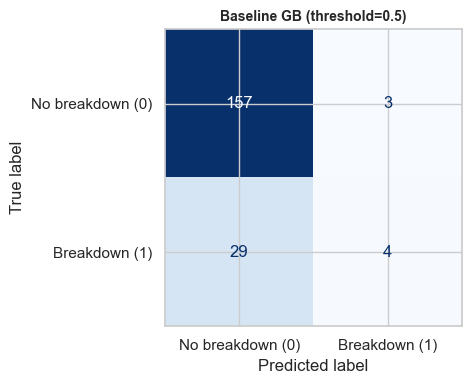


Predicciones clase 1 en val: 7 de 193


In [ ]:
# Baseline: GradientBoosting without engineered features, only original NUM+CAT
preprocessor_orig = ColumnTransformer([
    ('num', numeric_transformer, NUM_COLS),
    ('cat', categorical_transformer, CAT_COLS)
])

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor_orig),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=RANDOM_STATE
    ))
])

baseline_result = evaluate_model(
    'Baseline GB (threshold=0.5)', baseline_pipeline,
    X_train[NUM_COLS + CAT_COLS], y_train,
    X_val[NUM_COLS + CAT_COLS], y_val
)
results.append(baseline_result)

print(f'\nPredicciones clase 1 en val: {(baseline_result["y_prob"] >= 0.5).sum()} de {len(y_val)}')

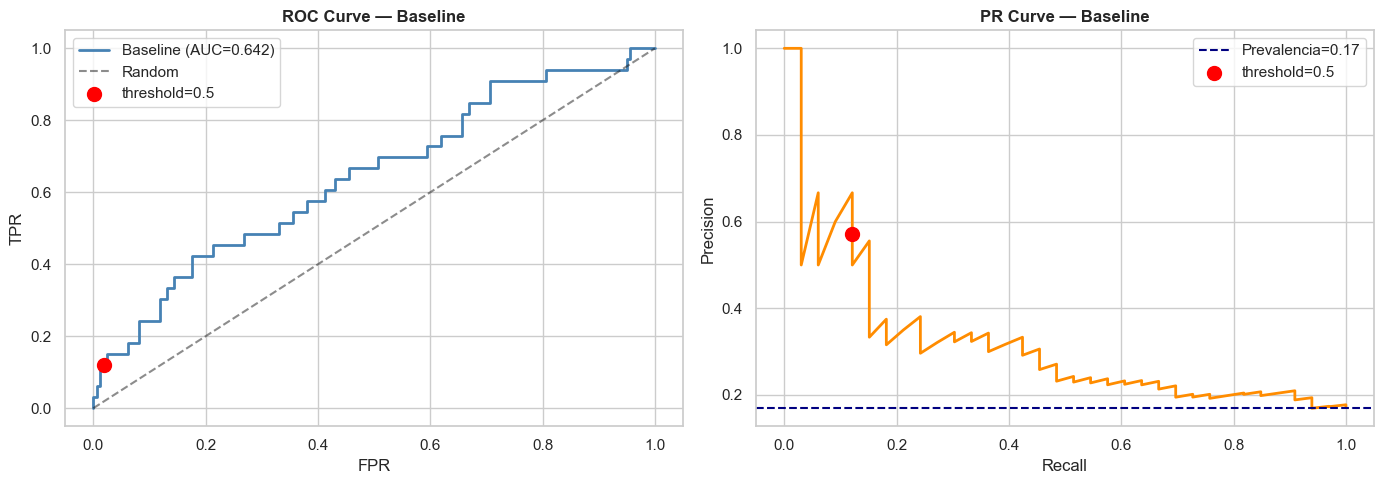

In [ ]:
# PR curve + ROC curve for baseline
y_prob_bl = baseline_result['y_prob']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_val, y_prob_bl)
auc_bl = roc_auc_score(y_val, y_prob_bl)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'Baseline (AUC={auc_bl:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.5, label='Random')
# Operating point a threshold=0.5
pred05 = (y_prob_bl >= 0.5).astype(int)
fpr_op = (pred05 & (y_val == 0)).sum() / (y_val == 0).sum()
tpr_op = (pred05 & (y_val == 1)).sum() / (y_val == 1).sum()
axes[0].scatter([fpr_op], [tpr_op], color='red', zorder=5, s=100, label='threshold=0.5')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve — Baseline', fontweight='bold')
axes[0].legend()

# PR curve
prec, rec, thr = precision_recall_curve(y_val, y_prob_bl)
axes[1].plot(rec, prec, color='darkorange', lw=2)
axes[1].axhline(y_val.mean(), color='navy', linestyle='--', label=f'Prevalencia={y_val.mean():.2f}')
# Operating point
p_op = precision_score(y_val, pred05, zero_division=0)
r_op = recall_score(y_val, pred05, zero_division=0)
axes[1].scatter([r_op], [p_op], color='red', zorder=5, s=100, label='threshold=0.5')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve — Baseline', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Threshold Analysis (Highest Impact)

The default threshold is 0.5, but with 17% real prevalence, the optimal should be ~0.17. We analyze how Class 1 F1 varies with the threshold.

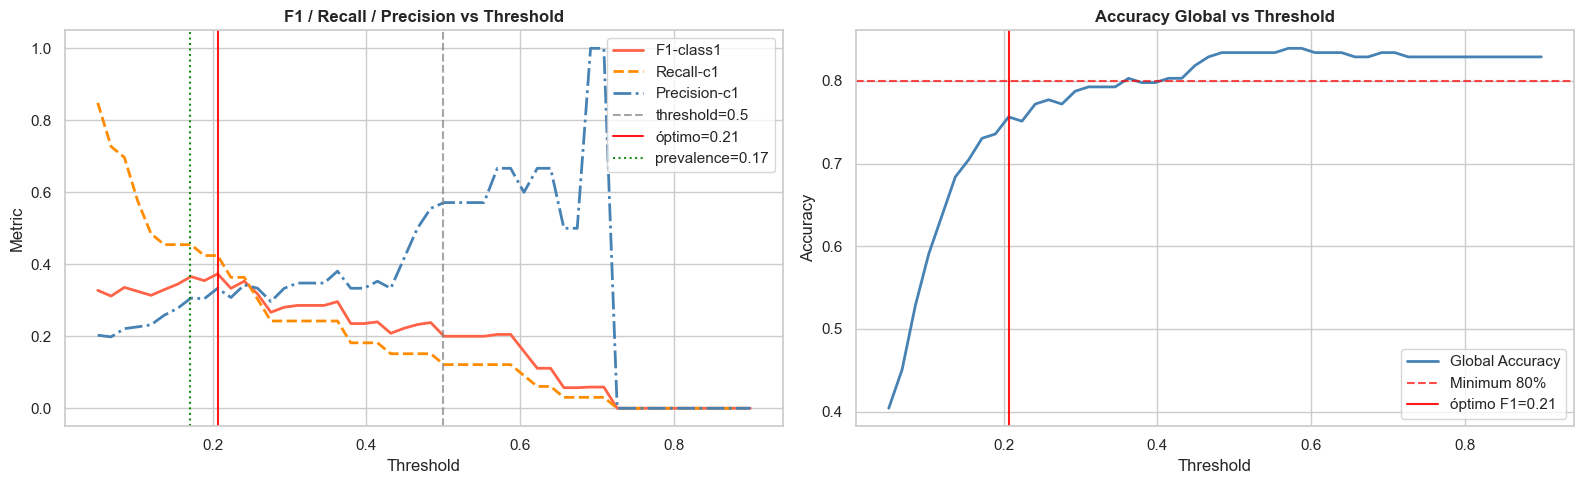

Threshold óptimo para F1-class1: 0.206
  F1-class1  : 0.3733
  Recall-c1  : 0.4242
  Accuracy   : 0.7565


In [ ]:
thresholds = np.linspace(0.05, 0.90, 50)
f1_scores = []
recall_scores = []
prec_scores = []
acc_scores = []

for t in thresholds:
    y_pred_t = (y_prob_bl >= t).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_t, pos_label=1, zero_division=0))
    recall_scores.append(recall_score(y_val, y_pred_t, pos_label=1, zero_division=0))
    prec_scores.append(precision_score(y_val, y_pred_t, pos_label=1, zero_division=0))
    acc_scores.append(accuracy_score(y_val, y_pred_t))

best_t_idx = np.argmax(f1_scores)
best_t = thresholds[best_t_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(thresholds, f1_scores,     label='F1-class1',  color='tomato',     lw=2)
axes[0].plot(thresholds, recall_scores, label='Recall-c1',  color='darkorange', lw=2, ls='--')
axes[0].plot(thresholds, prec_scores,   label='Precision-c1',color='steelblue', lw=2, ls='-.')
axes[0].axvline(0.5,    color='gray',  ls='--', alpha=0.7, label='threshold=0.5')
axes[0].axvline(best_t, color='red',   ls='-',  alpha=0.9, label=f'optimal={best_t:.2f}')
axes[0].axvline(0.17,   color='green', ls=':',  alpha=0.9, label='prevalence=0.17')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Metric')
axes[0].set_title('F1 / Recall / Precision vs Threshold', fontweight='bold')
axes[0].legend()

axes[1].plot(thresholds, acc_scores, color='steelblue', lw=2, label='Global Accuracy')
axes[1].axhline(0.80, color='red', ls='--', alpha=0.7, label='Minimum 80%')
axes[1].axvline(best_t, color='red', ls='-', alpha=0.9, label=f'optimal F1={best_t:.2f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Global vs Threshold', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Optimal Threshold for F1-class1: {best_t:.3f}')
print(f'  F1-class1  : {f1_scores[best_t_idx]:.4f}')
print(f'  Recall-c1  : {recall_scores[best_t_idx]:.4f}')
print(f'  Accuracy   : {acc_scores[best_t_idx]:.4f}')

In [ ]:
# Compare threshold=0.5 vs 0.17 vs optimal
for t, label in [(0.5, 'threshold=0.50'), (0.17, 'threshold=0.17 (prevalence)'), (best_t, f'threshold={best_t:.2f} (óptimo F1)')]:
    y_pred_t = (y_prob_bl >= t).astype(int)
    f1 = f1_score(y_val, y_pred_t, pos_label=1, zero_division=0)
    rec = recall_score(y_val, y_pred_t, pos_label=1, zero_division=0)
    acc = accuracy_score(y_val, y_pred_t)
    n_pos = y_pred_t.sum()
    print(f'{label:45s} | F1={f1:.3f} | Recall={rec:.3f} | Acc={acc:.3f} | n_class1={n_pos}')

threshold=0.50                                | F1=0.200 | Recall=0.121 | Acc=0.834 | n_class1=7
threshold=0.17 (prevalence)                   | F1=0.366 | Recall=0.455 | Acc=0.731 | n_class1=49
threshold=0.21 (óptimo F1)                    | F1=0.373 | Recall=0.424 | Acc=0.756 | n_class1=42


## 4. Sampling Strategies + Engineered Features

We use `imblearn.Pipeline` to apply SMOTE **within the pipeline**, avoiding data leakage. Oversampling is only applied to the training fold, never to validation.

<b>What does SMOTE mean?</b>

SMOTE is a technique for imbalanced datasets that helps classification models to better generalize by creating synthetic instances of the least frequent class, it also prevents overfitting since the points created are not just raw copies of the ones that already exists


  SMOTE + GradientBoosting + Eng. Features  [threshold=0.5]
  Accuracy global    : 0.8135
  Balanced Accuracy  : 0.5147
  F1 clase 1         : 0.1000
  Recall clase 1     : 0.0606
  Precision clase 1  : 0.2857
  ROC-AUC            : 0.5369

                  precision    recall  f1-score   support

No breakdown (0)       0.83      0.97      0.90       160
   Breakdown (1)       0.29      0.06      0.10        33

        accuracy                           0.81       193
       macro avg       0.56      0.51      0.50       193
    weighted avg       0.74      0.81      0.76       193



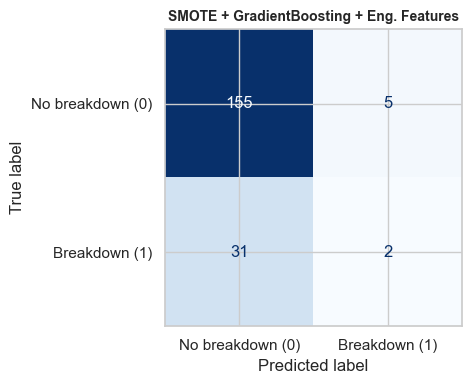

In [ ]:
# SMOTE + GradientBoosting (with engineered features)
smote_gb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=RANDOM_STATE
    ))
])

smote_gb_result = evaluate_model(
    'SMOTE + GradientBoosting + Eng. Features',
    smote_gb_pipeline, X_train, y_train, X_val, y_val, threshold=0.5
)
results.append(smote_gb_result)


  SMOTE + RandomForest (balanced)  [threshold=0.5]
  Accuracy global    : 0.8187
  Balanced Accuracy  : 0.5058
  F1 clase 1         : 0.0541
  Recall clase 1     : 0.0303
  Precision clase 1  : 0.2500
  ROC-AUC            : 0.5843

                  precision    recall  f1-score   support

No breakdown (0)       0.83      0.98      0.90       160
   Breakdown (1)       0.25      0.03      0.05        33

        accuracy                           0.82       193
       macro avg       0.54      0.51      0.48       193
    weighted avg       0.73      0.82      0.76       193



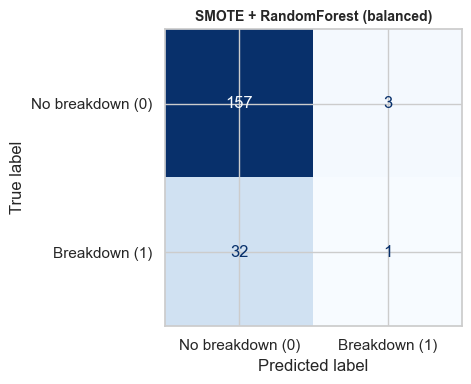

In [ ]:
# SMOTE + RandomForest class_weight='balanced'
smote_rf_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ))
])

smote_rf_result = evaluate_model(
    'SMOTE + RandomForest (balanced)',
    smote_rf_pipeline, X_train, y_train, X_val, y_val, threshold=0.5
)
results.append(smote_rf_result)


  BorderlineSMOTE + GradientBoosting  [threshold=0.5]
  Accuracy global    : 0.8290
  Balanced Accuracy  : 0.5241
  F1 clase 1         : 0.1081
  Recall clase 1     : 0.0606
  Precision clase 1  : 0.5000
  ROC-AUC            : 0.5519

                  precision    recall  f1-score   support

No breakdown (0)       0.84      0.99      0.91       160
   Breakdown (1)       0.50      0.06      0.11        33

        accuracy                           0.83       193
       macro avg       0.67      0.52      0.51       193
    weighted avg       0.78      0.83      0.77       193



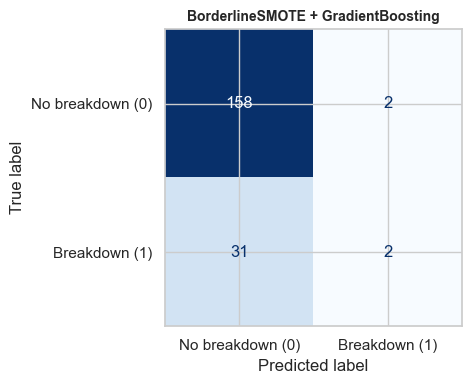

In [ ]:
# BorderlineSMOTE + GradientBoosting
bl_smote_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', BorderlineSMOTE(random_state=RANDOM_STATE)),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=RANDOM_STATE
    ))
])

bl_smote_result = evaluate_model(
    'BorderlineSMOTE + GradientBoosting',
    bl_smote_pipeline, X_train, y_train, X_val, y_val, threshold=0.5
)
results.append(bl_smote_result)


  SMOTETomek + GradientBoosting  [threshold=0.5]
  Accuracy global    : 0.8135
  Balanced Accuracy  : 0.5147
  F1 clase 1         : 0.1000
  Recall clase 1     : 0.0606
  Precision clase 1  : 0.2857
  ROC-AUC            : 0.5369

                  precision    recall  f1-score   support

No breakdown (0)       0.83      0.97      0.90       160
   Breakdown (1)       0.29      0.06      0.10        33

        accuracy                           0.81       193
       macro avg       0.56      0.51      0.50       193
    weighted avg       0.74      0.81      0.76       193



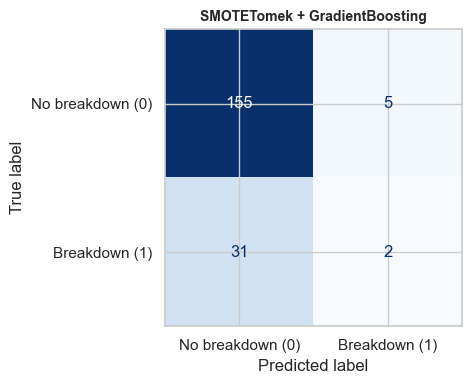

In [ ]:
# SMOTETomek (combined over+under) + GradientBoosting
smotetomek_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('sampler', SMOTETomek(random_state=RANDOM_STATE)),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=RANDOM_STATE
    ))
])

smotetomek_result = evaluate_model(
    'SMOTETomek + GradientBoosting',
    smotetomek_pipeline, X_train, y_train, X_val, y_val, threshold=0.5
)
results.append(smotetomek_result)

## 5. Decision Tree — University Requirement

Interpretable tree with `class_weight='balanced'` + GridSearchCV with `scoring='f1'`.

In [ ]:
# ── GridSearchCV for Decision Tree ────────────────────────────────────────
dt_pipeline_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

dt_param_grid = {
    'classifier__max_depth':         [3, 4, 5, 6, 7, 8],
    'classifier__min_samples_leaf':  [5, 10, 15, 20],
    'classifier__criterion':         ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    dt_pipeline_cv, dt_param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1', n_jobs=-1, verbose=0
)

dt_grid.fit(X_train, y_train)

print('Best hyperparameters (DT):')
print(dt_grid.best_params_)
print(f'Mejor F1 en CV: {dt_grid.best_score_:.4f}')

Best hyperparameters (DT):
{'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 5}
Mejor F1 en CV: 0.3254



  Decision Tree (best params, balanced)  [threshold=0.5]
  Accuracy global    : 0.5959
  Balanced Accuracy  : 0.5879
  F1 clase 1         : 0.3276
  Recall clase 1     : 0.5758
  Precision clase 1  : 0.2289
  ROC-AUC            : 0.5893

                  precision    recall  f1-score   support

No breakdown (0)       0.87      0.60      0.71       160
   Breakdown (1)       0.23      0.58      0.33        33

        accuracy                           0.60       193
       macro avg       0.55      0.59      0.52       193
    weighted avg       0.76      0.60      0.65       193



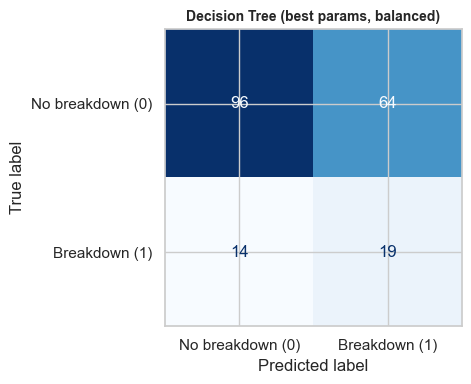

In [ ]:
dt_result = evaluate_model(
    'Decision Tree (best params, balanced)',
    dt_grid.best_estimator_,
    X_train, y_train, X_val, y_val, threshold=0.5
)
results.append(dt_result)

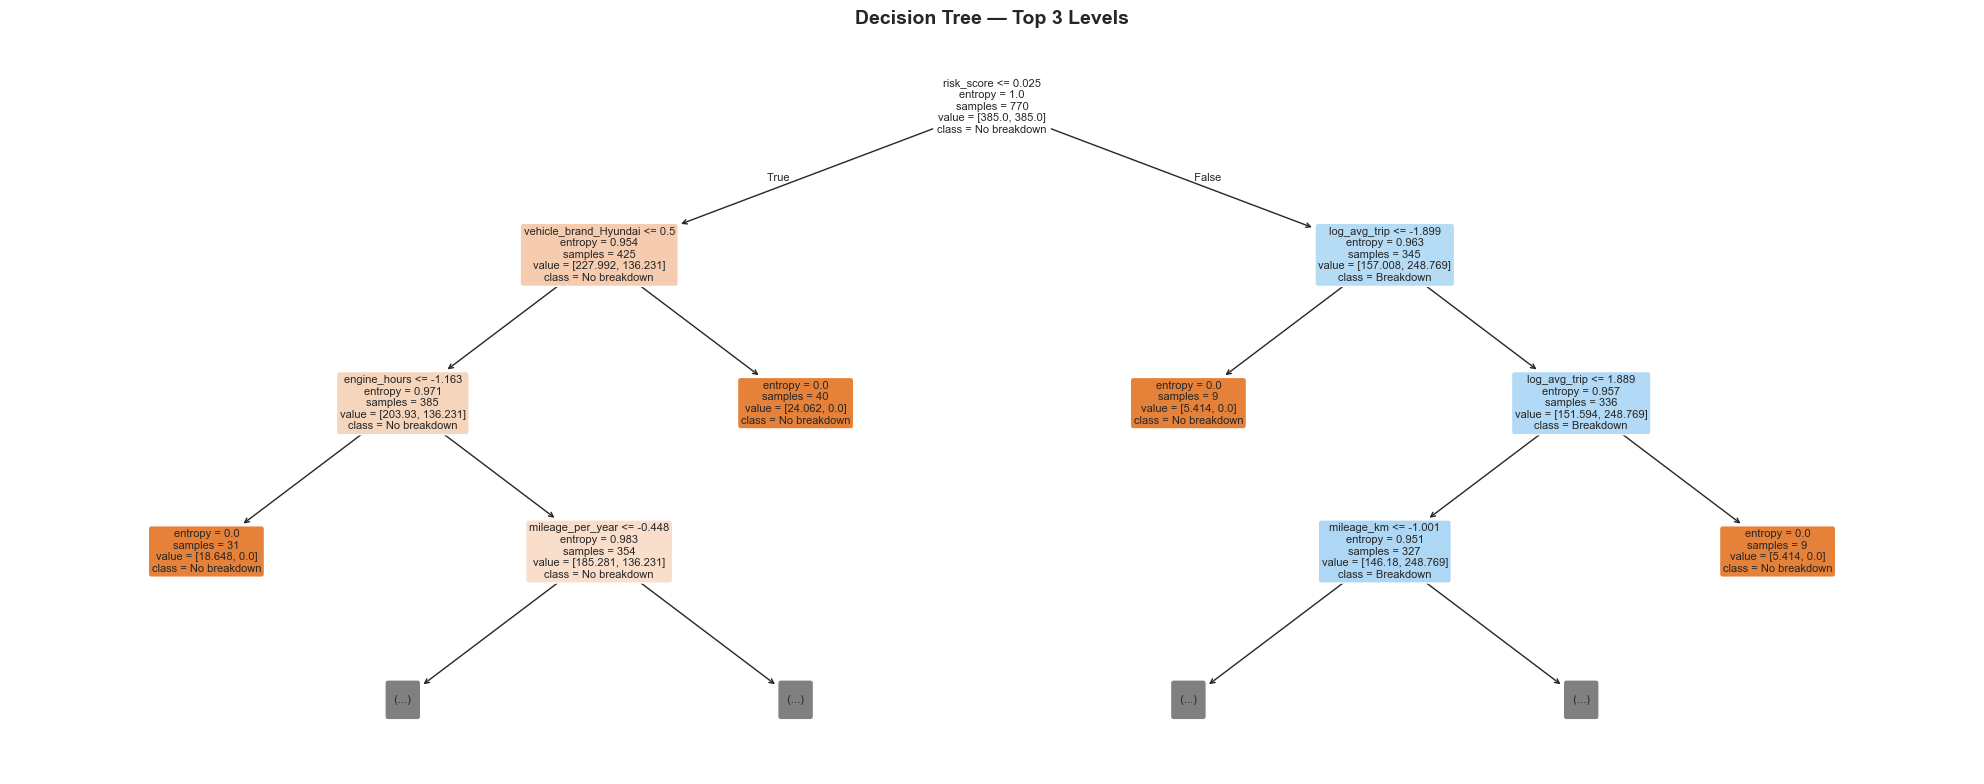

In [ ]:
# Visualize tree (top 3 levels)
best_dt = dt_grid.best_estimator_.named_steps['classifier']

# Get feature names
ohe_features = (
    dt_grid.best_estimator_.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(CAT_COLS)
    .tolist()
)
all_feature_names = ALL_NUM + ohe_features

plt.figure(figsize=(20, 8))
plot_tree(
    best_dt, max_depth=3,
    feature_names=all_feature_names,
    class_names=['No breakdown', 'Breakdown'],
    filled=True, rounded=True, fontsize=8
)
plt.title('Decision Tree — Top 3 Levels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Advanced Models — XGBoost & RandomForest Tuned

scale_pos_weight = 4.92 (neg/pos ratio)

  XGBoost (scale_pos_weight=4.9)  [threshold=0.5]
  Accuracy global    : 0.7772
  Balanced Accuracy  : 0.5529
  F1 clase 1         : 0.2456
  Recall clase 1     : 0.2121
  Precision clase 1  : 0.2917
  ROC-AUC            : 0.6193

                  precision    recall  f1-score   support

No breakdown (0)       0.85      0.89      0.87       160
   Breakdown (1)       0.29      0.21      0.25        33

        accuracy                           0.78       193
       macro avg       0.57      0.55      0.56       193
    weighted avg       0.75      0.78      0.76       193



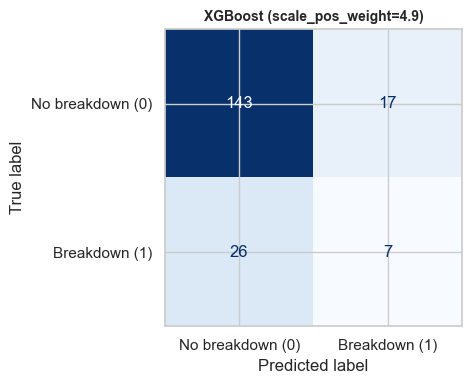

In [ ]:
# ── XGBoost with scale_pos_weight ────────────────────────────────────────────
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f'scale_pos_weight = {scale_pos_weight:.2f} (neg/pos ratio)')

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=RANDOM_STATE, verbosity=0
    ))
])

xgb_result = evaluate_model(
    f'XGBoost (scale_pos_weight={scale_pos_weight:.1f})',
    xgb_pipeline, X_train, y_train, X_val, y_val, threshold=0.5
)
results.append(xgb_result)

In [ ]:
# ── RandomForest with RandomizedSearchCV ────────────────────────────────────
rf_pipeline_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ))
])

rf_param_dist = {
    'classifier__n_estimators':   [100, 200, 300],
    'classifier__max_depth':      [5, 8, 10, 15, None],
    'classifier__min_samples_leaf': [2, 5, 10],
    'classifier__max_features':   ['sqrt', 'log2', 0.5]
}

rf_rand = RandomizedSearchCV(
    rf_pipeline_cv, rf_param_dist, n_iter=20,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1', n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)

rf_rand.fit(X_train, y_train)
print('Best hyperparameters (RF):')
print(rf_rand.best_params_)
print(f'Mejor F1 en CV: {rf_rand.best_score_:.4f}')

Best hyperparameters (RF):
{'classifier__n_estimators': 100, 'classifier__min_samples_leaf': 10, 'classifier__max_features': 'log2', 'classifier__max_depth': 8}
Mejor F1 en CV: 0.1830



  RandomForest (tuned, balanced)  [threshold=0.5]
  Accuracy global    : 0.7565
  Balanced Accuracy  : 0.6006
  F1 clase 1         : 0.3380
  Recall clase 1     : 0.3636
  Precision clase 1  : 0.3158
  ROC-AUC            : 0.6460

                  precision    recall  f1-score   support

No breakdown (0)       0.86      0.84      0.85       160
   Breakdown (1)       0.32      0.36      0.34        33

        accuracy                           0.76       193
       macro avg       0.59      0.60      0.59       193
    weighted avg       0.77      0.76      0.76       193



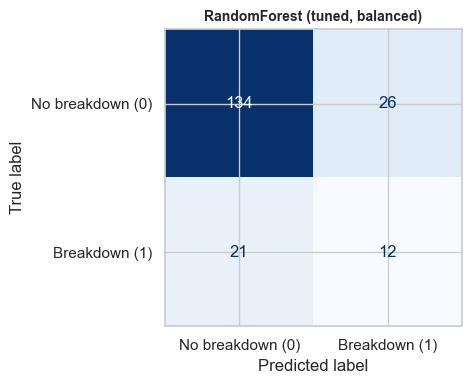

In [ ]:
rf_tuned_result = evaluate_model(
    'RandomForest (tuned, balanced)',
    rf_rand.best_estimator_,
    X_train, y_train, X_val, y_val, threshold=0.5
)
results.append(rf_tuned_result)

## 7. Cross-Validation with Correct Metrics

We use `StratifiedKFold` + `cross_validate` with F1, Balanced Accuracy, and ROC-AUC. **We do not use Accuracy.**

In [ ]:
cv_scoring = {
    'f1':                'f1',
    'balanced_accuracy': 'balanced_accuracy',
    'roc_auc':           'roc_auc'
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = [
    ('Baseline GB', baseline_pipeline),
    ('SMOTE+GB+Eng', smote_gb_pipeline),
    ('BorderlineSMOTE+GB', bl_smote_pipeline),
    ('XGBoost', xgb_pipeline),
    ('RF Tuned', rf_rand.best_estimator_),
    ('DT Best', dt_grid.best_estimator_),
]

print('Running 5-fold CV for all models...\n')

X_cv = X_train_full
y_cv = y_train_full

cv_results_list = []

for name, pipe in cv_models:
    # For baseline models using only original NUM+CAT
    X_use = X_cv[NUM_COLS + CAT_COLS] if name == 'Baseline GB' else X_cv
    
    cv_out = cross_validate(pipe, X_use, y_cv, cv=skf, scoring=cv_scoring, n_jobs=-1)
    row = {
        'Model': name,
        'F1 mean': round(cv_out['test_f1'].mean(), 4),
        'F1 std':  round(cv_out['test_f1'].std(), 4),
        'BalAcc':  round(cv_out['test_balanced_accuracy'].mean(), 4),
        'ROC-AUC': round(cv_out['test_roc_auc'].mean(), 4),
    }
    cv_results_list.append(row)
    print(f"{name:30s} F1={row['F1 mean']:.4f}±{row['F1 std']:.4f}  BalAcc={row['BalAcc']:.4f}  AUC={row['ROC-AUC']:.4f}")

cv_df = pd.DataFrame(cv_results_list).sort_values('F1 mean', ascending=False)
print('\n--- Tabla CV ---')
print(cv_df.to_string(index=False))

Running 5-fold CV for all models...

Baseline GB                    F1=0.0733±0.0240  BalAcc=0.5090  AUC=0.6032
SMOTE+GB+Eng                   F1=0.0780±0.0662  BalAcc=0.5039  AUC=0.5792
BorderlineSMOTE+GB             F1=0.0872±0.0627  BalAcc=0.5056  AUC=0.5880
XGBoost                        F1=0.2022±0.0507  BalAcc=0.5351  AUC=0.5756
RF Tuned                       F1=0.2676±0.0378  BalAcc=0.5588  AUC=0.6358
DT Best                        F1=0.3219±0.0501  BalAcc=0.5906  AUC=0.5791

--- Tabla CV ---
             Model  F1 mean  F1 std  BalAcc  ROC-AUC
           DT Best   0.3219  0.0501  0.5906   0.5791
          RF Tuned   0.2676  0.0378  0.5588   0.6358
           XGBoost   0.2022  0.0507  0.5351   0.5756
BorderlineSMOTE+GB   0.0872  0.0627  0.5056   0.5880
      SMOTE+GB+Eng   0.0780  0.0662  0.5039   0.5792
       Baseline GB   0.0733  0.0240  0.5090   0.6032


## 8. Model Comparison

In [ ]:
# Comparison table on validation
val_results_df = pd.DataFrame([{
    'Model': r['model'],
    'F1-class1': r['f1_class1'],
    'Balanced Acc': r['balanced_accuracy'],
    'ROC-AUC': r['roc_auc'],
    'Accuracy': r['accuracy'],
    'Recall-c1': r['recall_class1'],
    'Precision-c1': r['precision_class1'],
} for r in results]).sort_values('F1-class1', ascending=False)

print('=== VALIDATION COMPARISON ===')
print(val_results_df.to_string(index=False))

=== VALIDATION COMPARISON ===
                                   Model  F1-class1  Balanced Acc  ROC-AUC  Accuracy  Recall-c1  Precision-c1
          RandomForest (tuned, balanced)     0.3380        0.6006   0.6460    0.7565     0.3636        0.3158
   Decision Tree (best params, balanced)     0.3276        0.5879   0.5893    0.5959     0.5758        0.2289
          XGBoost (scale_pos_weight=4.9)     0.2456        0.5529   0.6193    0.7772     0.2121        0.2917
             Baseline GB (threshold=0.5)     0.2000        0.5512   0.6419    0.8342     0.1212        0.5714
      BorderlineSMOTE + GradientBoosting     0.1081        0.5241   0.5519    0.8290     0.0606        0.5000
SMOTE + GradientBoosting + Eng. Features     0.1000        0.5147   0.5369    0.8135     0.0606        0.2857
           SMOTETomek + GradientBoosting     0.1000        0.5147   0.5369    0.8135     0.0606        0.2857
         SMOTE + RandomForest (balanced)     0.0541        0.5058   0.5843    0.8187     0

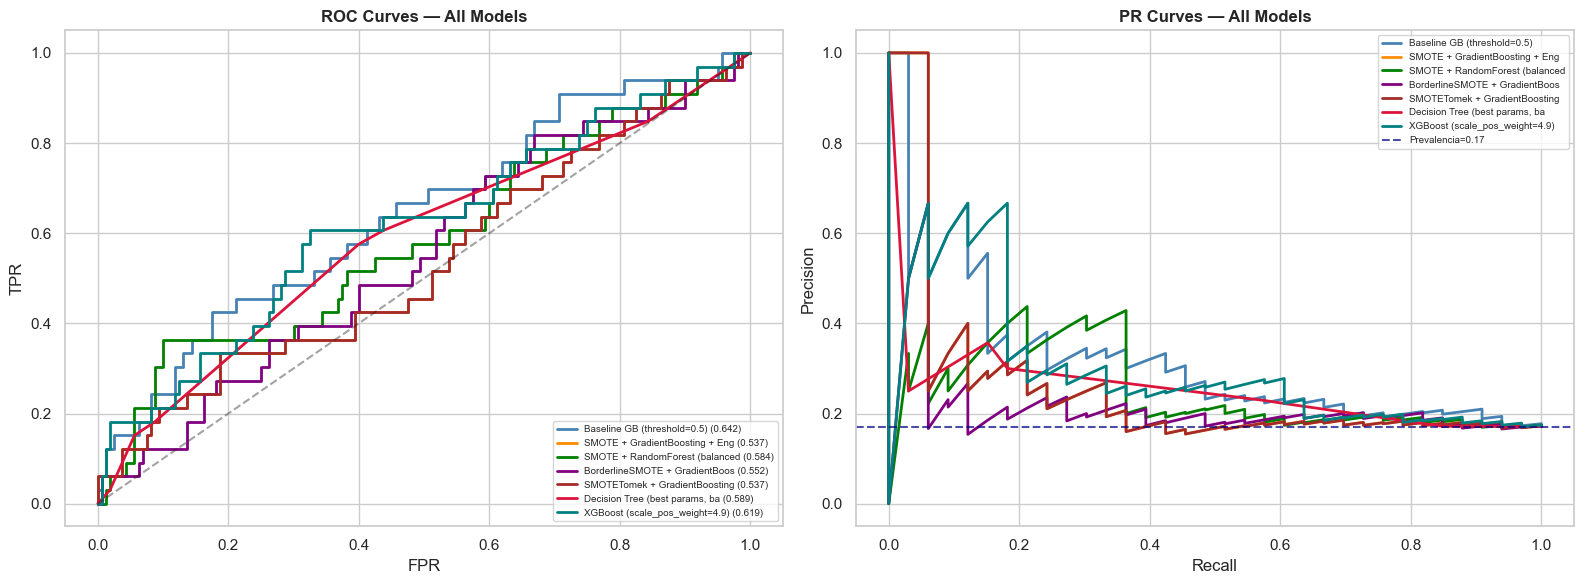

In [ ]:
# Overlaid ROC curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['steelblue', 'darkorange', 'green', 'purple', 'brown', 'crimson', 'teal']

# Results with y_prob available
results_with_prob = [r for r in results if 'y_prob' in r and r['y_prob'] is not None]

for r, color in zip(results_with_prob, colors):
    fpr_, tpr_, _ = roc_curve(y_val, r['y_prob'])
    auc_ = r['roc_auc']
    axes[0].plot(fpr_, tpr_, lw=2, color=color, label=f"{r['model'][:30]} ({auc_:.3f})")

axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].legend(fontsize=7, loc='lower right')

# PR curves
for r, color in zip(results_with_prob, colors):
    prec_, rec_, _ = precision_recall_curve(y_val, r['y_prob'])
    axes[1].plot(rec_, prec_, lw=2, color=color, label=r['model'][:30])

axes[1].axhline(y_val.mean(), color='navy', ls='--', alpha=0.7, label=f'Prevalencia={y_val.mean():.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves — All Models', fontweight='bold')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 9. Threshold Optimization of the Best Model

We choose the best model by Class 1 F1 on validation and optimize the threshold with the constraint `accuracy >= 0.80`.

In [ ]:
# Select best model by Class 1 F1 (excluding baseline)
non_baseline = [r for r in results if 'Baseline' not in r['model']]
best_result = max(non_baseline, key=lambda r: r['f1_class1'])
print(f'Best model: {best_result["model"]}')
print(f'  F1-class1  : {best_result["f1_class1"]}')
print(f'  ROC-AUC    : {best_result["roc_auc"]}')

best_pipeline = best_result['pipeline']
y_prob_best   = best_result['y_prob']

Mejor modelo: RandomForest (tuned, balanced)
  F1-class1  : 0.338
  ROC-AUC    : 0.646


Threshold óptimo: 0.558
  F1-class1  : 0.3200
  Recall-c1  : 0.2424
  Precision-c1: 0.4706
  Accuracy   : 0.8238


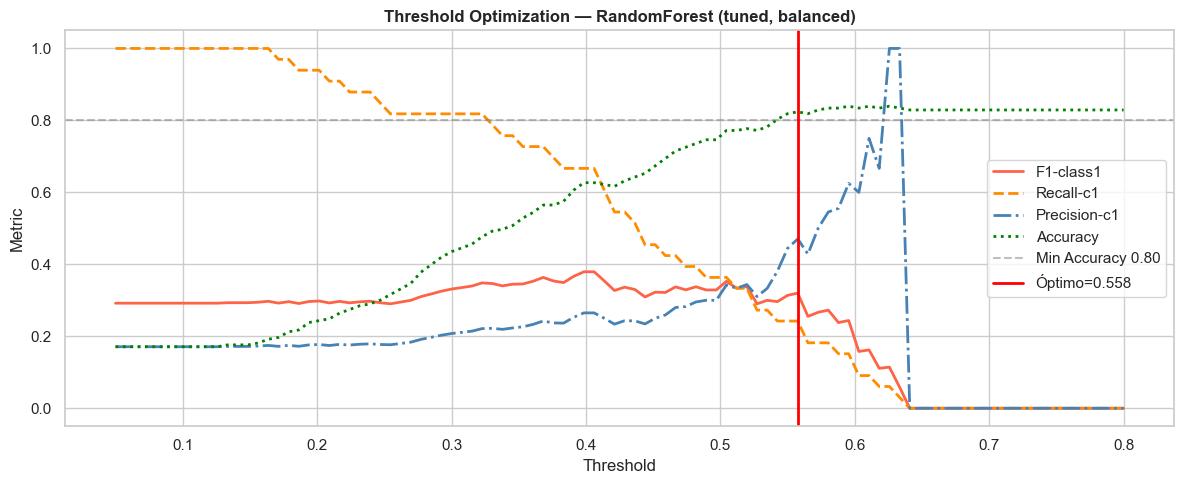

In [ ]:
# Threshold sweep with accuracy constraint >= 0.80
thresholds2 = np.linspace(0.05, 0.80, 100)
results_thr  = []

for t in thresholds2:
    y_pred_t = (y_prob_best >= t).astype(int)
    f1 = f1_score(y_val, y_pred_t, pos_label=1, zero_division=0)
    rec = recall_score(y_val, y_pred_t, pos_label=1, zero_division=0)
    prec = precision_score(y_val, y_pred_t, pos_label=1, zero_division=0)
    acc = accuracy_score(y_val, y_pred_t)
    results_thr.append({'threshold': t, 'f1': f1, 'recall': rec, 'precision': prec, 'accuracy': acc})

thr_df = pd.DataFrame(results_thr)

# Optimal threshold: max F1 with accuracy >= 0.80 and recall >= 0.40
thr_filtered = thr_df[(thr_df['accuracy'] >= 0.80) & (thr_df['recall'] >= 0.40)]
if len(thr_filtered) > 0:
    opt_row = thr_filtered.loc[thr_filtered['f1'].idxmax()]
else:
    # If none, relax the constraint
    thr_filtered = thr_df[thr_df['accuracy'] >= 0.78]
    opt_row = thr_filtered.loc[thr_filtered['f1'].idxmax()] if len(thr_filtered) > 0 else thr_df.loc[thr_df['f1'].idxmax()]

opt_threshold = opt_row['threshold']
print(f'Threshold óptimo: {opt_threshold:.3f}')
print(f'  F1-class1  : {opt_row["f1"]:.4f}')
print(f'  Recall-c1  : {opt_row["recall"]:.4f}')
print(f'  Precision-c1: {opt_row["precision"]:.4f}')
print(f'  Accuracy   : {opt_row["accuracy"]:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thr_df['threshold'], thr_df['f1'],       label='F1-class1',   color='tomato', lw=2)
ax.plot(thr_df['threshold'], thr_df['recall'],   label='Recall-c1',   color='darkorange', lw=2, ls='--')
ax.plot(thr_df['threshold'], thr_df['precision'],label='Precision-c1',color='steelblue', lw=2, ls='-.')
ax.plot(thr_df['threshold'], thr_df['accuracy'], label='Accuracy',    color='green', lw=2, ls=':')
ax.axhline(0.80, color='gray', ls='--', alpha=0.5, label='Min Accuracy 0.80')
ax.axvline(opt_threshold, color='red', lw=2, label=f'Óptimo={opt_threshold:.3f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Metric')
ax.set_title(f'Threshold Optimization — {best_result["model"][:50]}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


  RandomForest (tuned, balanced) [threshold=0.558]  [threshold=0.5575757575757576]
  Accuracy global    : 0.8238
  Balanced Accuracy  : 0.5931
  F1 clase 1         : 0.3200
  Recall clase 1     : 0.2424
  Precision clase 1  : 0.4706
  ROC-AUC            : 0.6460

                  precision    recall  f1-score   support

No breakdown (0)       0.86      0.94      0.90       160
   Breakdown (1)       0.47      0.24      0.32        33

        accuracy                           0.82       193
       macro avg       0.66      0.59      0.61       193
    weighted avg       0.79      0.82      0.80       193



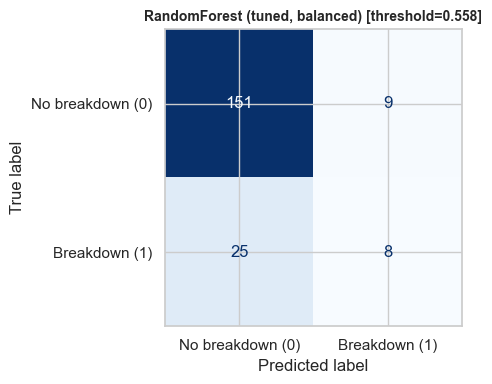


=== RESULTADO FINAL vs OBJETIVOS ===
  ❌ Recall-c1      : actual=0.242  objetivo>=0.5
  ✅ Precision-c1   : actual=0.471  objetivo>=0.4
  ✅ Accuracy       : actual=0.824  objetivo>=0.8


In [ ]:
# Final evaluation with optimal threshold
final_result = evaluate_model(
    f'{best_result["model"][:40]} [threshold={opt_threshold:.3f}]',
    best_pipeline,
    X_train, y_train, X_val, y_val,
    threshold=opt_threshold
)

print('\n=== FINAL RESULTS vs OBJECTIVES ===')
targets = {'Recall-c1': 0.50, 'Precision-c1': 0.40, 'Accuracy': 0.80}
actuals = {'Recall-c1': final_result['recall_class1'],
           'Precision-c1': final_result['precision_class1'],
           'Accuracy': final_result['accuracy']}
for k, target in targets.items():
    actual = actuals[k]
    status = '✅' if actual >= target else '❌'
    print(f'  {status} {k:15s}: actual={actual:.3f}  objetivo>={target}')

## 10. Final Submission

We retrain on **all training data** (963 rows) and generate predictions with the optimal threshold.

In [ ]:
# ── Retrain on Full Train Set ───────────────────────────────────────
print(f'Re-training "{best_result["model"]}" over {X_train_full.shape[0]} rows...')

X_use_full = X_train_full if 'Baseline' not in best_result['model'] else X_train_full[NUM_COLS + CAT_COLS]
best_pipeline.fit(X_use_full, y_train_full)

print(f'✅ Model retrained')
print(f'   Threshold : {opt_threshold:.3f}')

# ── Predictions on Test ─────────────────────────────────────────────────
X_test_use = X_test_sub if 'Baseline' not in best_result['model'] else X_test_sub[NUM_COLS + CAT_COLS]
y_pred_final, y_prob_final = predict_with_threshold(best_pipeline, X_test_use, threshold=opt_threshold)

print(f'\nPrediction distribution on test:')
unique, counts = np.unique(y_pred_final, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Clase {u}: {c} ({c/len(y_pred_final)*100:.1f}%)')

expected_class1 = int(len(y_pred_final) * 0.17)
actual_class1 = (y_pred_final == 1).sum()
print(f'\nExpected (~17%): ~{expected_class1} class 1')
print(f'Predicted: {actual_class1} class 1')

Re-entrenando "RandomForest (tuned, balanced)" sobre 963 filas...
✅ Model retrained
   Threshold de predicción: 0.558

Prediction distribution on test:
  Clase 0: 411 (91.3%)
  Clase 1: 39 (8.7%)

Esperado (~17% prevalencia): ~76 clase 1
Predicho: 39 clase 1


In [ ]:
# ── Save Submission ──────────────────────────────────────────────────────
submission = pd.DataFrame({
    'id': df_test_raw['id'],
    'breakdown_next_30_days': y_pred_final
})

# Check format
sample_sub = pd.read_csv('car-breakdown-prediction/sample_submission.csv')
assert list(submission.columns) == list(sample_sub.columns), 'ERROR: columns do not match'
assert len(submission) == len(sample_sub), f'ERROR: {len(submission)} rows vs {len(sample_sub)} expected'

output_path = 'car-breakdown-prediction/MySubmissions3.csv'
submission.to_csv(output_path, index=False)

print(f'✅ Submission saved: {output_path}')
print(f'   Rows: {len(submission)}')
print(f'   Class 1: {submission["breakdown_next_30_days"].sum()} ({submission["breakdown_next_30_days"].mean()*100:.1f}%)')
print()
print('First 10 rows:')
print(submission.head(10).to_string(index=False))

✅ Submission guardada: car-breakdown-prediction/MySubmissions3.csv
   Filas: 450
   Clase 1: 39 (8.7%)

First 10 rows:
  id  breakdown_next_30_days
1356                       1
 889                       0
1190                       0
 122                       0
1101                       0
 782                       0
 366                       0
1138                       0
 241                       0
1240                       0


In [ ]:
print('='*65)
print('FINAL SUMMARY')
print('='*65)
print(f'Winning model      : {best_result["model"]}')
print(f'Best Threshold     : {opt_threshold:.3f}')
print()
print('Metrics on validation (with optimal threshold):')
print(f'  Accuracy global  : {final_result["accuracy"]:.4f}')
print(f'  Balanced Accuracy: {final_result["balanced_accuracy"]:.4f}')
print(f'  F1 clase 1       : {final_result["f1_class1"]:.4f}')
print(f'  Recall clase 1   : {final_result["recall_class1"]:.4f}')
print(f'  Precision clase 1: {final_result["precision_class1"]:.4f}')
print(f'  ROC-AUC          : {final_result["roc_auc"]:.4f}')
print()
print(f'Predictions submission: {submission["breakdown_next_30_days"].sum()} class 1 out of {len(submission)} total')
print('='*65)

FINAL SUMMARY
Modelo ganador      : RandomForest (tuned, balanced)
Threshold óptimo    : 0.558

Metrics on validation (with optimal threshold):
  Accuracy global  : 0.8238
  Balanced Accuracy: 0.5931
  F1 clase 1       : 0.3200
  Recall clase 1   : 0.2424
  Precision clase 1: 0.4706
  ROC-AUC          : 0.6460

Predicciones submission: 39 clase 1 de 450 total
